
 Encoded Data
     Bread  Butter   Cake    Egg   Milk   Rice    Tea
0    False   False  False   True   True  False  False
1    False    True  False   True  False  False   True
2    False   False   True  False   True  False   True
3    False   False   True  False   True  False  False
4    False   False  False   True  False   True  False
..     ...     ...    ...    ...    ...    ...    ...
995   True   False   True   True   True  False  False
996   True   False   True   True  False  False  False
997  False   False  False  False   True  False   True
998  False   False   True   True   True   True  False
999  False   False   True  False   True  False  False

[1000 rows x 7 columns]

 Frequent Item :     support               itemsets
0     0.431                (Bread)
1     0.403               (Butter)
2     0.406                 (Cake)
3     0.447                  (Egg)
4     0.448                 (Milk)
5     0.436                 (Rice)
6     0.430                  (Tea)
7     0.155   

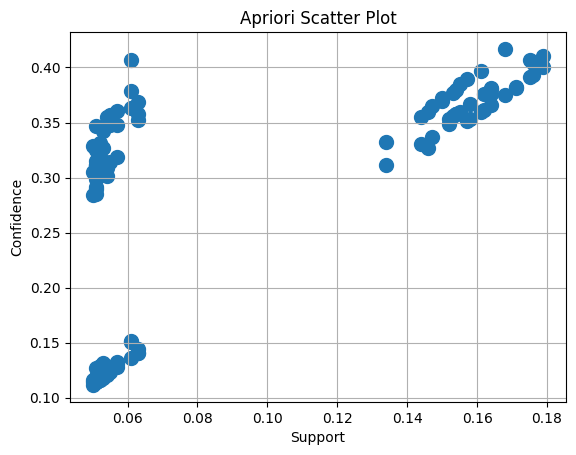

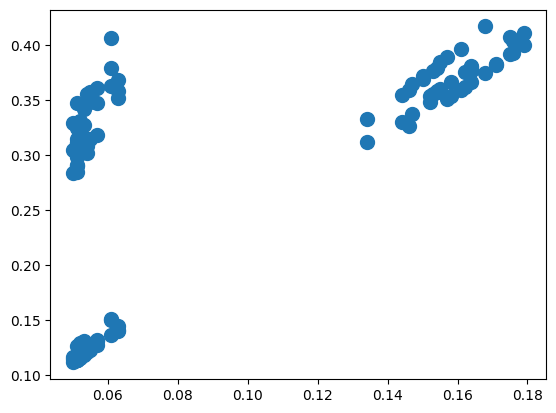

In [10]:
from mlxtend.frequent_patterns import apriori,association_rules
from mlxtend.preprocessing import TransactionEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
items =[
    'Bread',
    'Butter',
    'Milk',
    'Tea',
    'Rice',
    'Cake',
    'Egg'
]

transactions =[]
for i in range(1000):
    transaction_size = np.random.randint(2,5)
    transaction=list(
        map(str,
            np.random.choice(
                items,transaction_size,replace=False
            )
        )
    )
    transactions.append(transaction)

te = TransactionEncoder()
encoded_data = te.fit_transform(transactions)

Data = pd.DataFrame(
    encoded_data,
    columns=te.columns_
)
print("\n Encoded Data")
print(Data)

frequent_items = apriori(Data,min_support=0.05,use_colnames=True)
print(f"\n Frequent Item : {frequent_items}")

rules=association_rules(frequent_items,metric='confidence',min_threshold=0.01)
print(f"Threshold Rules : {rules}")


plt.scatter(rules['support'],rules['confidence'],s=100)
plt.xlabel("Support")
plt.ylabel("Confidence")

plt.title("Apriori Scatter Plot")

plt.grid(True)

plt.show()

plt.scatter(
    rules['support'],
    rules['confidence'],
    s=100
)

